In [ ]:
#Vanishing Gradients using Randoom data
from keras.src.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.datasets import mnist

np.random.seed(42)

X = np.random.randn(2000, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def build_model():
    model = Sequential()

    model.add(Dense(32, activation='sigmoid', input_shape=(2,)))

    for _ in range(8):
          model.add(Dense(32, activation='sigmoid'))

    model.add(Dense(1, activation='sigmoid'))


    model.compile(
      optimizer=Adam(learning_rate=0.001),
      loss='binary_crossentropy'
    )
    return model

sigmoid_model = build_model()

sigmoid_history = sigmoid_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32
)

plt.plot(sigmoid_history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Vanishing Gradient using Sigmoid (10 Layers)")
plt.grid()
plt.show()


**1.Vanishing Gradients using MNIST**

Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0983 - loss: 2.5418
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0975 - loss: 2.3617
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0995 - loss: 2.3156
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1127 - loss: 2.3042
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1127 - loss: 2.3018
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1127 - loss: 2.3013
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1127 - loss: 2.3013
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1127 - loss: 2.3013
Epoch 9/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1127 - loss: 2.3013
Epoch 10/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1127 - loss: 2.3013
Epoch 11/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1127 - loss: 2.3013
Epoch 12/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

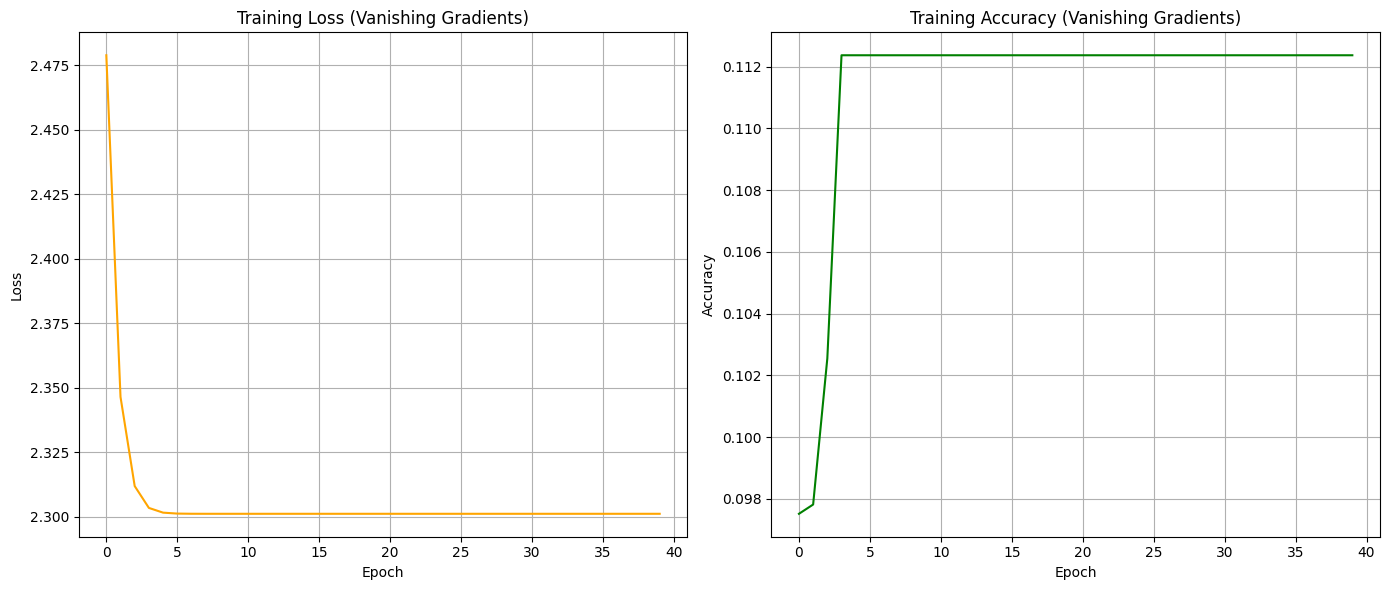

In [ ]:
# Vanishing Gradients using MNIST

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.initializers import RandomNormal
from keras.optimizers import SGD

tf.random.set_seed(42)
np.random.seed(42)

(X_train, y_train), _ = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_train = X_train.reshape(-1, 784)

y_train = keras.utils.to_categorical(y_train, 10)

model = Sequential()

model.add(Dense(128,activation="sigmoid",kernel_initializer=RandomNormal(mean=0.0, stddev=0.1),input_shape=(784,)))

for _ in range(3):
  model.add(Dense(64,activation="sigmoid",kernel_initializer=RandomNormal(mean=0.0, stddev=0.001)))

model.add(Dense(10,activation="softmax"))

model.compile(optimizer=SGD(learning_rate=0.001),loss="categorical_crossentropy",metrics=["accuracy"])

history = model.fit(X_train,y_train,epochs=40,batch_size=128,verbose=1)


plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], color="orange")
plt.title("Training Loss (Vanishing Gradients)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], color="green")
plt.title("Training Accuracy (Vanishing Gradients)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
#Exploding gradients using random data.
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from keras.datasets import mnist
from keras.initializers import RandomNormal

tf.random.set_seed(42)

X = np.random.randn(1000,2)
y = np.random.randn(1000,2)

model = Sequential()

model.add(Dense(64,activation='relu',kernel_initializer=RandomNormal(mean=0,stddev=0.3),input_shape = (2,)))

for _ in range(8):
  model.add(Dense(32,activation='relu',kernel_initializer=RandomNormal(mean=0,stddev=0.3)))

model.add(Dense(1))


model.compile(optimizer=SGD(learning_rate=0.05),loss='mse')
history = model.fit(X,y,epochs=20,batch_size=32)

#log values
print(history.history)

In [ ]:
#Eploding gradients in DL using random data

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

X = np.random.rand(500, 2) * 10
y = 2 * X + 1 + np.random.randn(500, 2) * 2

X = X.astype(np.float32)
y = y.astype(np.float32)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        1,
        activation='linear',
        kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=5.0),
        bias_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=5.0)
    )
])

optimizer = tf.keras.optimizers.SGD(learning_rate=0.5)
loss_fn = tf.keras.losses.MeanSquaredError()

n_epochs = 50
gradient_norms = []
losses = []

# Initial weights
model.build(input_shape=(None, 2))
w, b = model.trainable_variables
print(f"Initial weight: {w.numpy()[0][0]:.4f}, Initial bias: {b.numpy()[0]:.4f}\n")

for epoch in range(n_epochs):
    with tf.GradientTape() as tape:
        y_pred = model(X, training=True)
        loss = loss_fn(y, y_pred)

    grads = tape.gradient(loss, model.trainable_variables)

    # Gradient magnitude (L2 norm)
    grad_norm = tf.linalg.global_norm(grads)
    gradient_norms.append(grad_norm.numpy())
    losses.append(loss.numpy())

    # Apply gradients
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(gradient_norms)
plt.yscale("log")
plt.title("Exploding Gradients (Keras)")
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(losses, color="orange")
plt.yscale("log")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)

plt.tight_layout()
plt.show()


**2.Exploding Gradients using MNIST**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1098 - loss: 9676817942183936.0000
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 9/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 10/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 11/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 12/40
469/469 ━━━━━━━━━━━━━━━━━

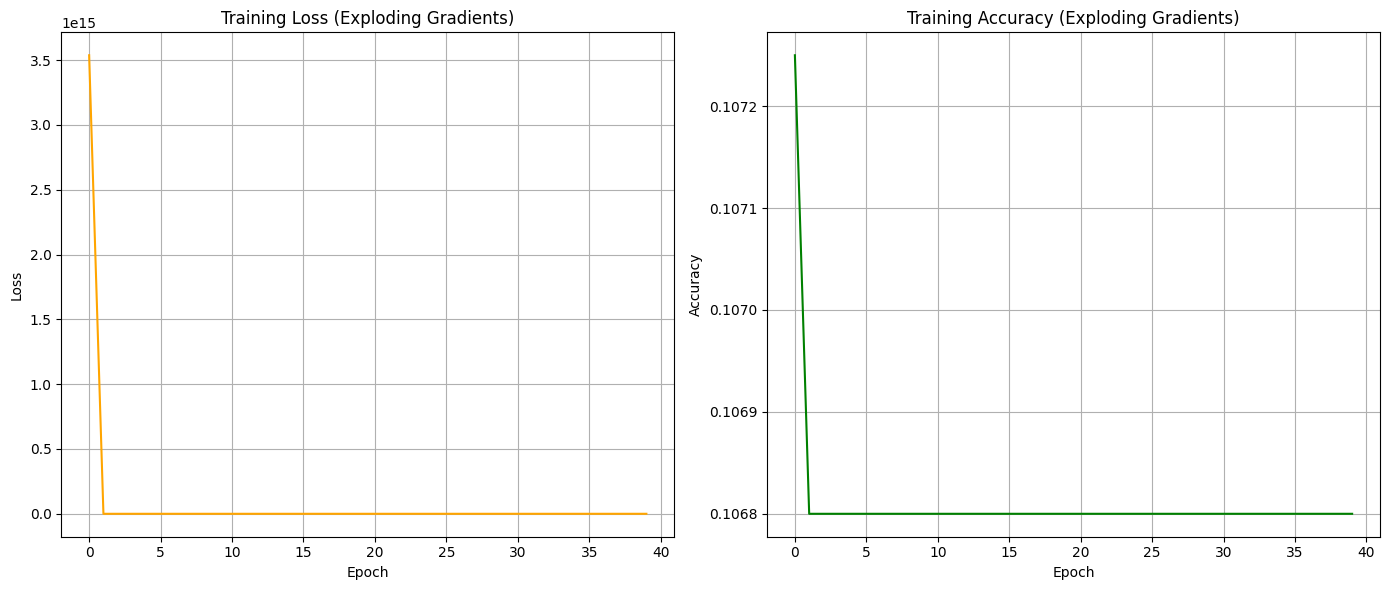

In [ ]:
# Exploding Gradients using MNIST

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.initializers import RandomNormal
from keras.optimizers import SGD

tf.random.set_seed(42)
np.random.seed(42)

(X_train, y_train), _ = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_train = X_train.reshape(-1, 784)

y_train = keras.utils.to_categorical(y_train, 10)

model = Sequential()

model.add(Dense(128,activation="relu",kernel_initializer=RandomNormal(mean=0.0, stddev=5.0),input_shape=(784,)))

model.add(Dense(64,activation="relu",kernel_initializer=RandomNormal(mean=0.0, stddev=5.0)))

model.add(Dense(10, activation="softmax"))

model.compile(optimizer=SGD(learning_rate=0.8),loss="categorical_crossentropy",metrics=["accuracy"])

history = model.fit(X_train,y_train,epochs=40,batch_size=128,verbose=1)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], color="orange")
plt.title("Training Loss (Exploding Gradients)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], color="green")
plt.title("Training Accuracy (Exploding Gradients)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
#Xaiver
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.datasets import mnist
from keras.initializers import GlorotNormal

np.random.seed(42)

X = np.random.randn(2000, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def build_model():
    model = Sequential()

    model.add(Dense(32, activation='sigmoid',kernel_initializer='GlorotNormal' ,input_shape=(2,)))

    for _ in range(8):
          model.add(Dense(32, activation='sigmoid',kernel_initializer='GlorotNormal'))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',loss = 'binary_crossentropy')

    return model

sigmoid_model = build_model()
sigmoid_history = sigmoid_model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=128
)

plt.plot(sigmoid_history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Sigmoid when using Xaiver (10 Layers)")
plt.grid()
plt.show()


**3.Xavier + Sigmoid using MNIST**

Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4277 - loss: 1.7602
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9096 - loss: 0.3670
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9419 - loss: 0.2190
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9579 - loss: 0.1585
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9666 - loss: 0.1236
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9735 - loss: 0.1011
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9776 - loss: 0.0846
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9809 - loss: 0.0716
Epoch 9/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9839 - loss: 0.0611
Epoch 10/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9864 - loss: 0.0525
Epoch 11/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9883 - loss: 0.0452
Epoch 12/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/ste

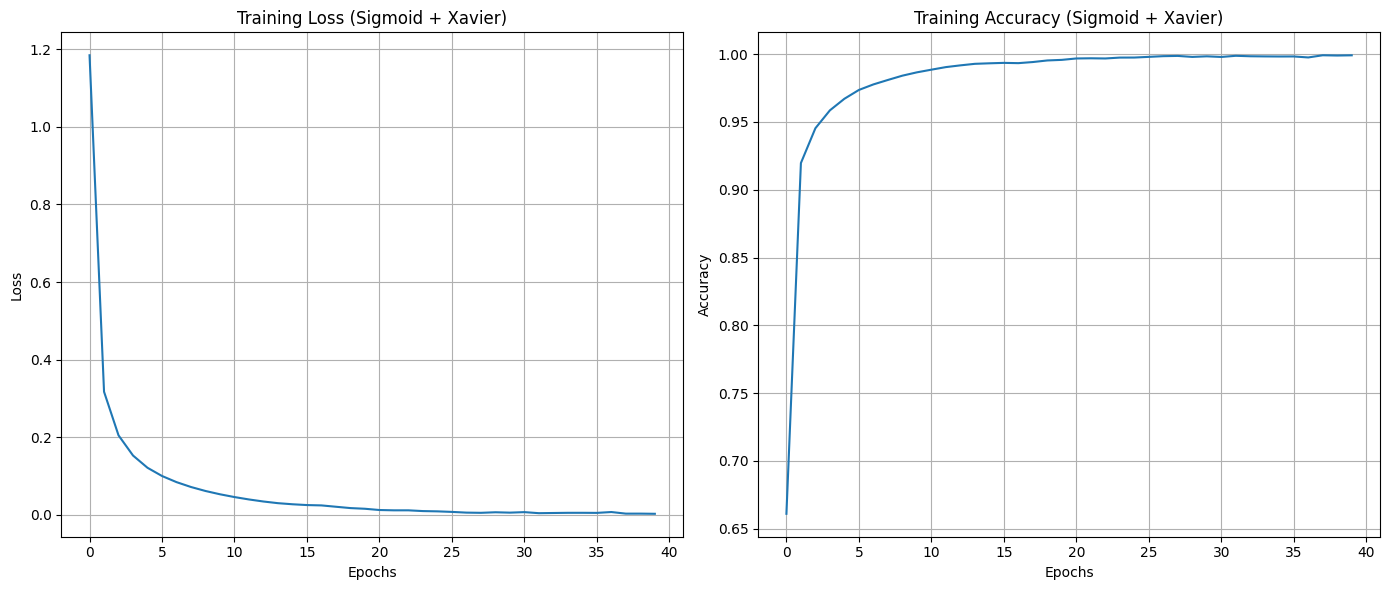

In [ ]:
#Xaiver using mnist

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.datasets import mnist
from keras.initializers import GlorotNormal

np.random.seed(42)
tf.random.set_seed(42)

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 784)
X_test  = X_test.reshape(-1, 784)

y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test, 10)

def build_model():
    model = Sequential()

    model.add(Dense(128,activation='sigmoid',kernel_initializer=GlorotNormal(),input_shape=(784,)))

    for _ in range(3):
        model.add(Dense(64,activation='sigmoid',kernel_initializer=GlorotNormal()))

    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer='Adam',loss='categorical_crossentropy',metrics=['accuracy'])

    return model

model = build_model()

history = model.fit(X_train, y_train,epochs=40,batch_size=128,verbose=1)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss (Sigmoid + Xavier)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy (Sigmoid + Xavier)")
plt.grid(True)

plt.tight_layout()
plt.show()


****

**4.He + ReLU using MNIST**

Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8095 - loss: 0.6148
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9634 - loss: 0.1273
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9745 - loss: 0.0878
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9798 - loss: 0.0645
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9845 - loss: 0.0497
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9870 - loss: 0.0424
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9897 - loss: 0.0315
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9900 - loss: 0.0322
Epoch 9/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9918 - loss: 0.0247
Epoch 10/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9912 - loss: 0.0246
Epoch 11/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9932 - loss: 0.0208
Epoch 12/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/ste

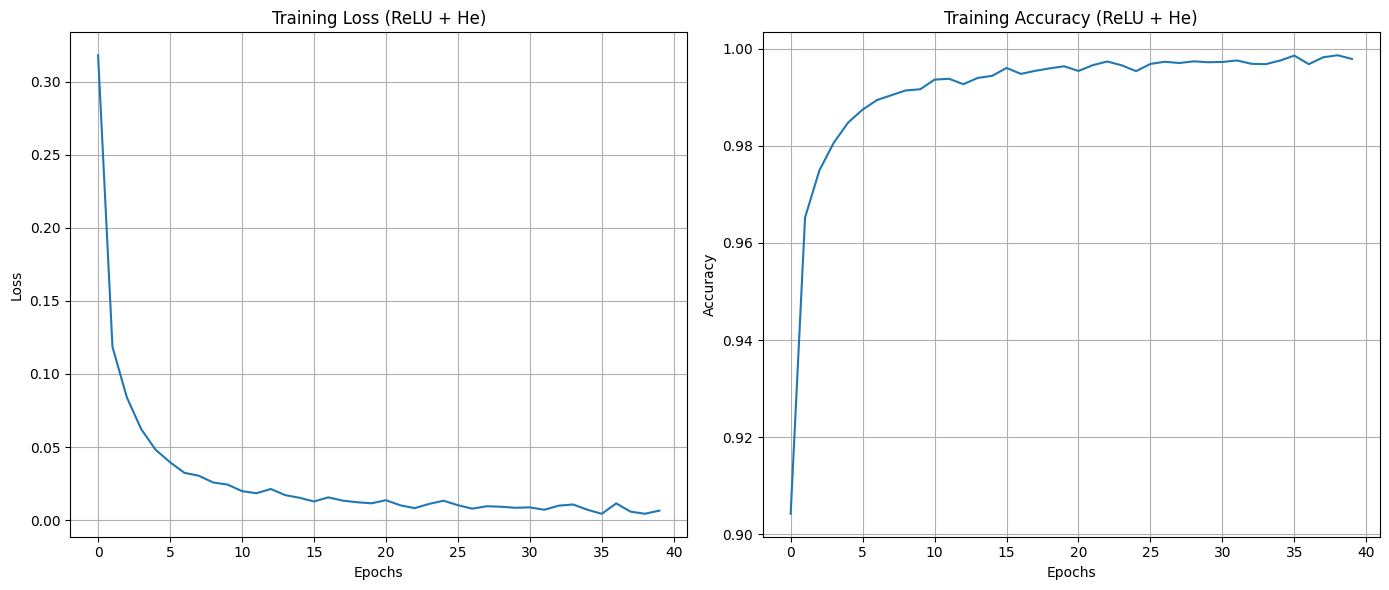

In [ ]:
# ReLU + He Initialization using MNIST

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.datasets import mnist
from keras.initializers import HeNormal

np.random.seed(42)
tf.random.set_seed(42)

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 784)
X_test  = X_test.reshape(-1, 784)

y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test, 10)

def build_model():
    model = Sequential()

    model.add(Dense(128,activation='relu',kernel_initializer=HeNormal(),input_shape=(784,)))

    for _ in range(3):
        model.add(Dense(64,activation='relu',kernel_initializer=HeNormal()))

    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

    return model

model = build_model()

history = model.fit(X_train, y_train,epochs=40,batch_size=128,verbose=1)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss (ReLU + He)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy (ReLU + He)")
plt.grid(True)

plt.tight_layout()
plt.show()


**5.Using Adam Optimizer**

**5.ReLU + He with SGD**

Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4274 - loss: 1.7634
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8756 - loss: 0.4364
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9075 - loss: 0.3203
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9215 - loss: 0.2739
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9297 - loss: 0.2440
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9358 - loss: 0.2219
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9406 - loss: 0.2043
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9454 - loss: 0.1897
Epoch 9/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9496 - loss: 0.1773
Epoch 10/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9529 - loss: 0.1664
Epoch 11/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9552 - loss: 0.1569
Epoch 12/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step

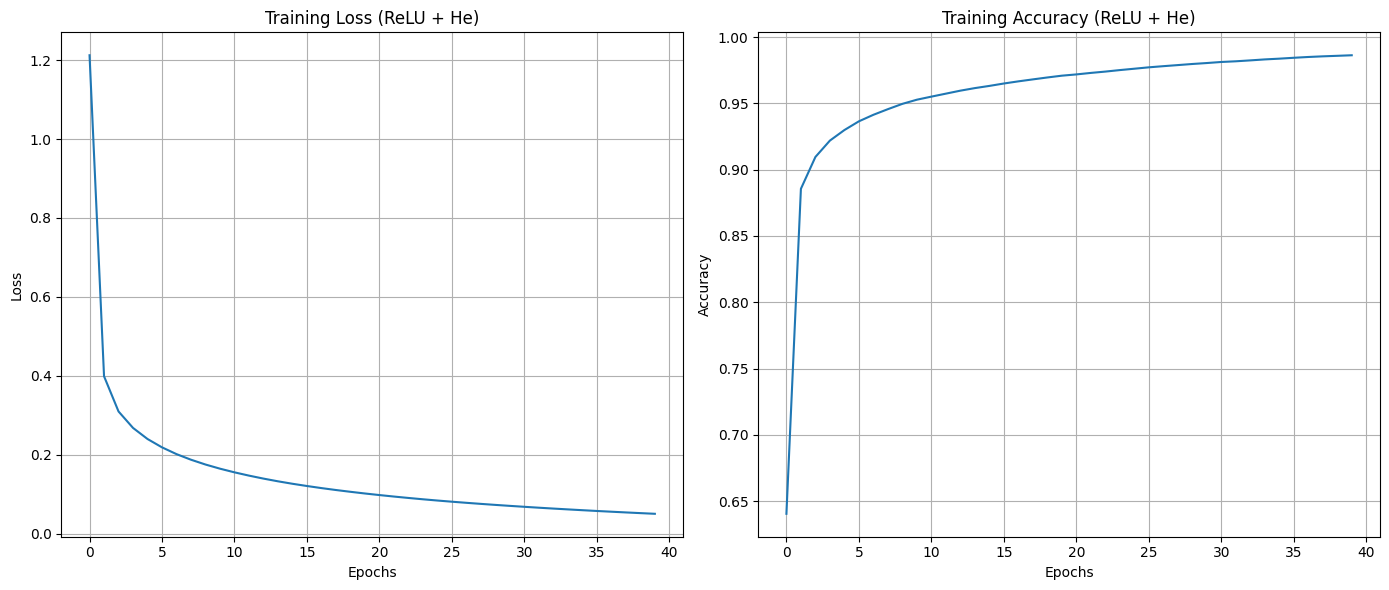

In [ ]:
# ReLU + He Initialization using MNIST – SGD

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.datasets import mnist
from keras.initializers import HeNormal

np.random.seed(42)
tf.random.set_seed(42)

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 784)
X_test  = X_test.reshape(-1, 784)

y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test, 10)

def build_model():
    model = Sequential()

    model.add(Dense(128,activation='relu',kernel_initializer=HeNormal(),input_shape=(784,)))

    for _ in range(3):
        model.add(Dense(64,activation='relu',kernel_initializer=HeNormal()))

    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer='SGD',loss='categorical_crossentropy',metrics=['accuracy'])

    return model

model = build_model()

history = model.fit(X_train, y_train,epochs=40,batch_size=128,verbose=1)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss (ReLU + He)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy (ReLU + He)")
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
#He initilizer using Adam
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.datasets import mnist
from keras.initializers import HeNormal

np.random.seed(42)

X = np.random.randn(2000, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def build_model():
    model = Sequential()

    model.add(Dense(32, activation='relu',kernel_initializer='HeNormal',input_shape=(2,)))

    for _ in range(8):
          model.add(Dense(32, activation='relu',kernel_initializer='HeNormal'))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='Adam',loss = 'binary_crossentropy')

    return model

relu_model = build_model()
relu_history = relu_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64
)

plt.plot(relu_history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ReLU Performance when He is used(10 Layers)")
plt.grid()
plt.show()
